# Random Forest Regression Model

This notebook trains a **Random Forest Regressor** using the common preprocessed dataset.

**Prerequisite:** Run `00_common_preprocessing.ipynb` first to generate the preprocessed data.

**Note:** Random Forest does NOT require feature scaling, so we use unscaled data.

In [42]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Common Preprocessed Data

Random Forest uses **unscaled** features (tree-based algorithms are scale-invariant).

In [ ]:
# Load preprocessed data (UNSCALED for Random Forest)
data_dir = '../data/preprocessed'  

X_train = pd.read_csv(f'{data_dir}/X_train.csv')
X_test = pd.read_csv(f'{data_dir}/X_test.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{data_dir}/y_test.csv').squeeze()
feature_names = joblib.load(f'{data_dir}/feature_names.pkl')

print("=" * 50)
print("COMMON PREPROCESSED DATA LOADED")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Feature names: {feature_names}")
print(f"\nUsing UNSCALED data (Random Forest is scale-invariant).")

COMMON PREPROCESSED DATA LOADED
Training set: 5285 samples
Testing set:  1322 samples
Features: 19
Feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Using UNSCALED data (Random Forest is scale-invariant).


## 2. Train Random Forest Model

In [ ]:
# Initialize and train the Random Forest Regressor 
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max features: {rf_model.max_features}")

Random Forest model trained successfully!
Number of trees: 100
Max features: 1.0


## 3. Evaluate the Model

In [ ]:
# Make prediction
y_train_pred = rf_model.predict(X_train)
y_pred = rf_model.predict(X_test)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Random Forest Results =====")
print(f"\n--- Training Set ---")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")
print(f"\n--- Testing Set ---")  
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

if train_r2 - r2 > 0.1:   
    print(f"\n⚠ Gap between train and test R²: {train_r2 - r2:.4f} — may indicate overfitting.") 

===== Random Forest Results =====

--- Training Set ---
MAE  : 0.4552
RMSE : 0.9071
R²   : 0.9465

--- Testing Set ---
MAE  : 1.1314
RMSE : 2.2095
R²   : 0.6546

⚠ Gap between train and test R²: 0.2919 — may indicate overfitting.


## 4. Cross-Validation

In [ ]:
# Cross-validation for robustness
X_all = pd.concat([X_train, X_test]) 
y_all = pd.concat([y_train, y_test])

cv_scores = cross_val_score(rf_model, X_all, y_all, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores : {cv_scores.round(4)}")
print(f"Mean CV R²                 : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-Validation R² Scores : [0.6461 0.7727 0.609  0.4924 0.6551]
Mean CV R²                 : 0.6351 (+/- 0.0900)


## 5. Visualizations

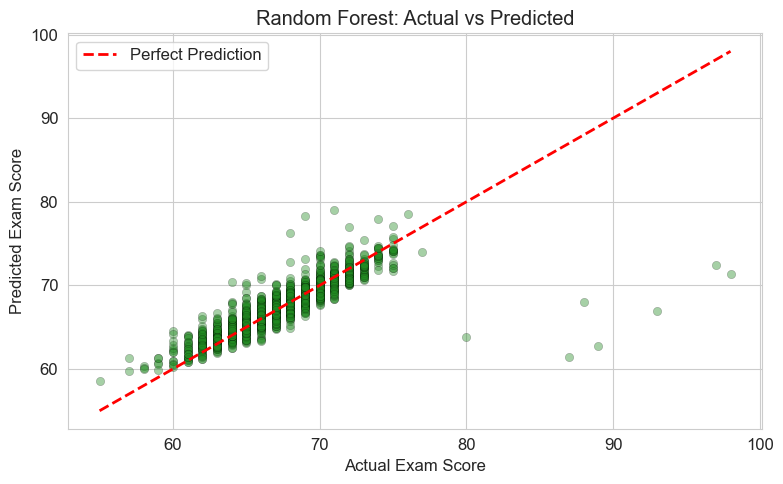

In [ ]:
# Plot: Actual vs Predicted
plt.figure(figsize=(8, 5)) 
plt.scatter(y_test, y_pred, alpha=0.4, color='forestgreen', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

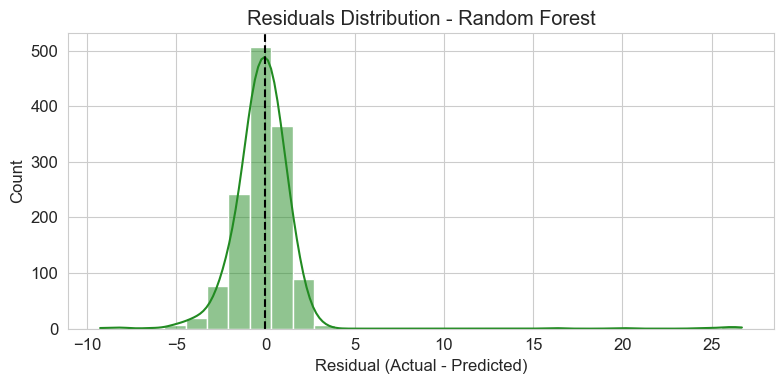

In [48]:
# Plot: Residuals distribution
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='forestgreen')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution - Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

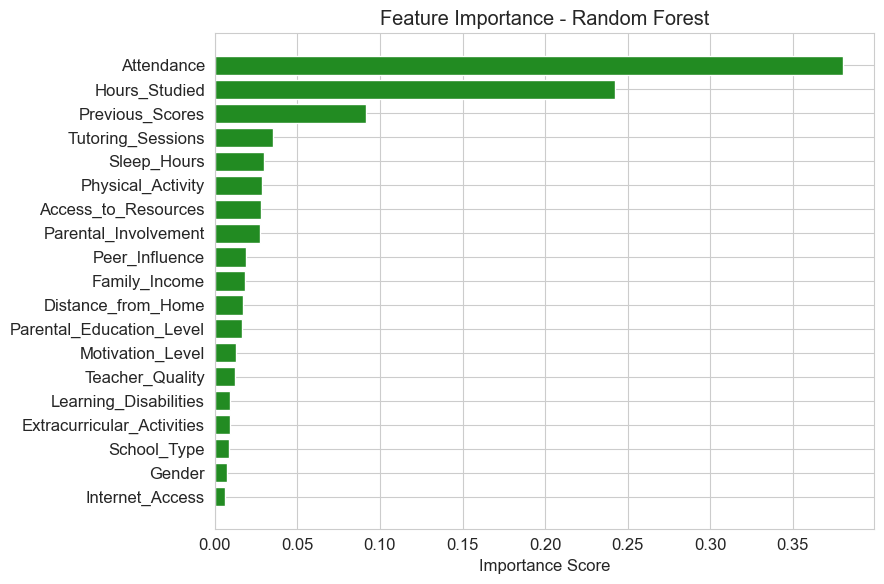

In [ ]:
# Plot: Feature Importance
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='forestgreen')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show() 

## 6. Save the Model

In [ ]:
# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/random_forest_model.pkl')

# Save metrics for comparison
metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
joblib.dump(metrics, '../models/random_forest_metrics.pkl')

print("Model saved to ../models/random_forest_model.pkl")
print(f"Metrics saved: {metrics}") 

Model saved to ../models/random_forest_model.pkl
Metrics saved: {'MAE': 1.1313993948562784, 'RMSE': np.float64(2.209454464742382), 'R2': 0.6546399715264632}
